In [1]:
# These modules are required for working with the data.
from dysh.fits.gbtfitsload import GBTFITSLoad
from dysh.log import init_logging
from astropy import units as u

# These modules are used for file I/O
from dysh.util.files import dysh_data
from pathlib import Path

In [2]:
init_logging(2)

# also create a local "output" directory where temporary notebook files can be stored.
output_dir = Path.cwd() / "output"
output_dir.mkdir(exist_ok=True)

In [3]:
filename = dysh_data(test="getps")

16:05:30.405 I Resolving test=getps -> AGBT05B_047_01/AGBT05B_047_01.raw.acs/


In [4]:
sdfits = GBTFITSLoad(filename)

16:05:30.530 I Index loaded from .index file (44/93 columns). Missing columns (TCAL, WCS, calibration metadata, etc.) will be automatically loaded from FITS file when first accessed.


In [5]:
sdfits.summary()

SCAN,OBJECT,VELOCITY,PROC,PROCSEQN,RESTFREQ,# IF,# POL,# INT,# FEED,AZIMUTH,ELEVATION
51,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,198.3431,18.6427
52,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,198.9306,18.7872
53,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,199.3305,18.3561
54,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,199.9157,18.4927
55,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,200.3042,18.0575
56,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,200.8906,18.1860
57,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,202.3275,17.3853
58,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,202.9192,17.4949


In [6]:
sdfits["TCAL", "PLNUM", "CAL", "INTNUM"]

16:05:30.593 I Column(s) ['TCAL'] not available in .index file. Loading from FITS file(s)...


,TCAL,PLNUM,CAL,INTNUM
0,1.424292,1,T,0
1,1.424292,1,F,0
2,1.452650,0,T,0
3,1.452650,0,F,0
4,1.424292,1,T,1
...,...,...,...,...
347,1.452650,0,F,9
348,1.424292,1,T,10
349,1.424292,1,F,10
350,1.452650,0,T,10


In [7]:
ps_original = sdfits.getps(plnum=0, ifnum=0, fdnum=0).timeaverage()
ps_original.baseline(degree=1, remove=True) 

In [8]:
sdfits["TCAL"] *= 1.2

16:05:33.791 W Changing an existing SDFITS column TCAL


/bigdisk/src/dysh/src/dysh/fits/sdfitsload.py:1497: UserWarning: Changing an existing SDFITS column TCAL
  warnings.warn(f"Changing an existing SDFITS column {items}")  # noqa: B028


In [9]:
sdfits["TCAL", "PLNUM"]

,TCAL,PLNUM
0,1.70915,1
1,1.70915,1
2,1.74318,0
3,1.74318,0
4,1.70915,1
...,...,...
347,1.74318,0
348,1.70915,1
349,1.70915,1
350,1.74318,0


In [10]:
ps_updated = sdfits.getps(plnum=0, ifnum=0, fdnum=0).timeaverage()
ps_updated.baseline(degree=1, remove=True) 

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


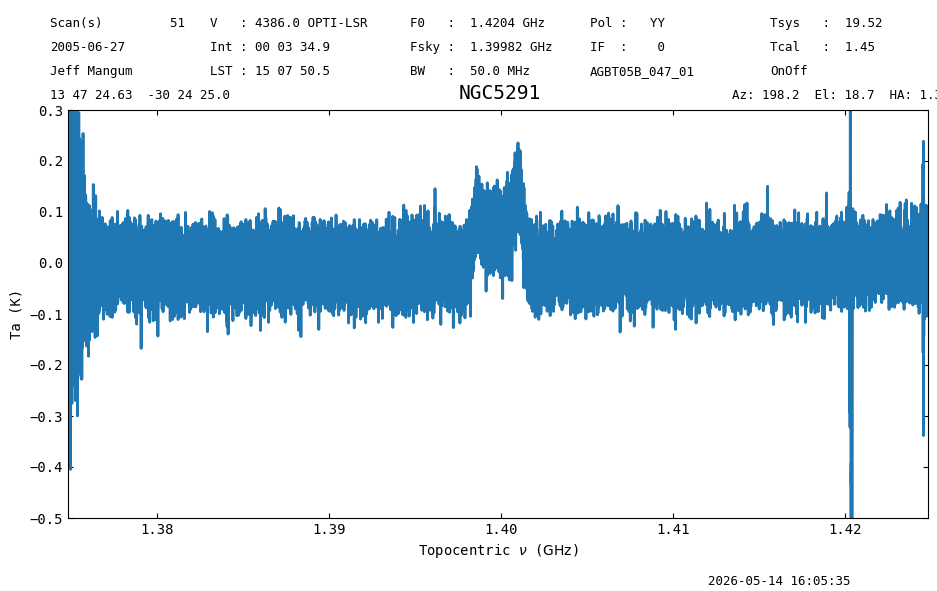

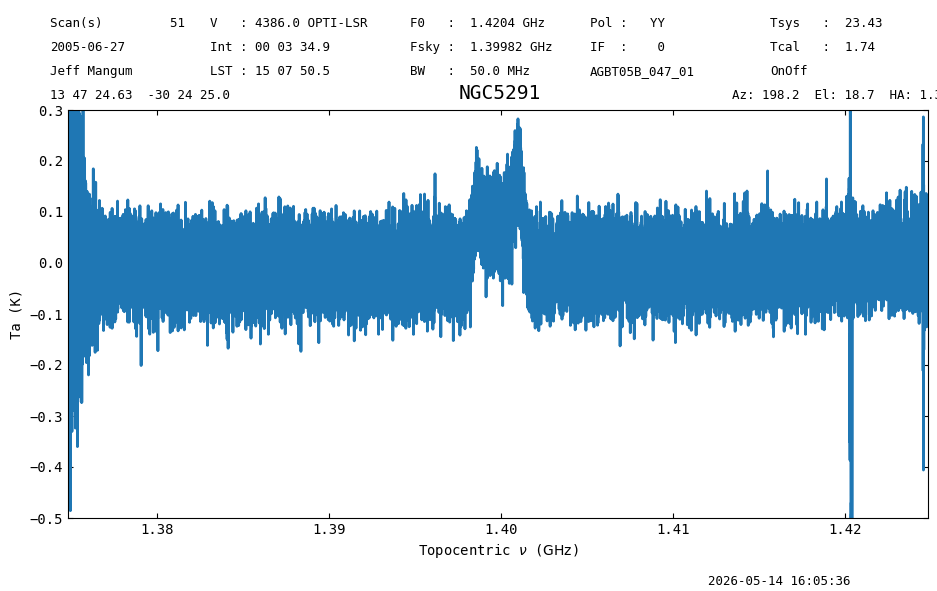

In [11]:
ps_original.plot(ymin=-0.5, ymax=0.3)
ps_updated.plot(ymin=-0.5, ymax=0.3)

In [12]:
ps_updated.check_stats(0.07192832 * u.K)

16:05:37.128 I rms is OK 
